**SpongeWorks**

--- 
- intro and brief outline 
- data sourcing 
- data processing 
- results visualisation 
- references etc ...
---


# Import packages

In [ ]:
import os
import sys
from datetime import datetime
from glob import glob
from pathlib import Path
import cdsapi
import geopandas as gpd
import hvplot.xarray
import imageio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import openeo
import pandas as pd
import xarray as xr
from openeo.api.process import Parameter
from pyproj import Transformer
from shapely.geometry import Point, box
from pyproj import Transformer


## Aux functions 

In [ ]:
def assign_lon_lat_to_xarray(data, lon, lat):
    """
    Assigns longitude and latitude values to xarray's x and y coordinates.

    Args:
        lai_data (xr.Dataset): The xarray Dataset.
        lon (np.ndarray): 2D array of longitude values.
        lat (np.ndarray): 2D array of latitude values.

    Returns:
        xr.Dataset: The xarray Dataset with updated coordinates.
    """

    # Ensure lon and lat match the shape of the x and y dimensions.
    if lon.shape != (data.y.size, data.x.size) or lat.shape != (data.y.size, data.x.size):
        raise ValueError("lon and lat arrays do not match the shape of xarray's x and y dimensions.")

    # Extract 1D arrays to assign to x and y coordinates.
    new_lon_x = lon[0, :]  # First row of lon (representing x)
    new_lat_y = lat[:, 0]  # First column of lat (representing y)

    # Assign the new coordinates:
    data = data.assign_coords({"x": new_lon_x, "y": new_lat_y})

    return data


# Areas of interest

/var/folders/c7/cgtth_8n0zn5_c2ywwdcb5980000gn/T/ipykernel_85490/1226801993.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


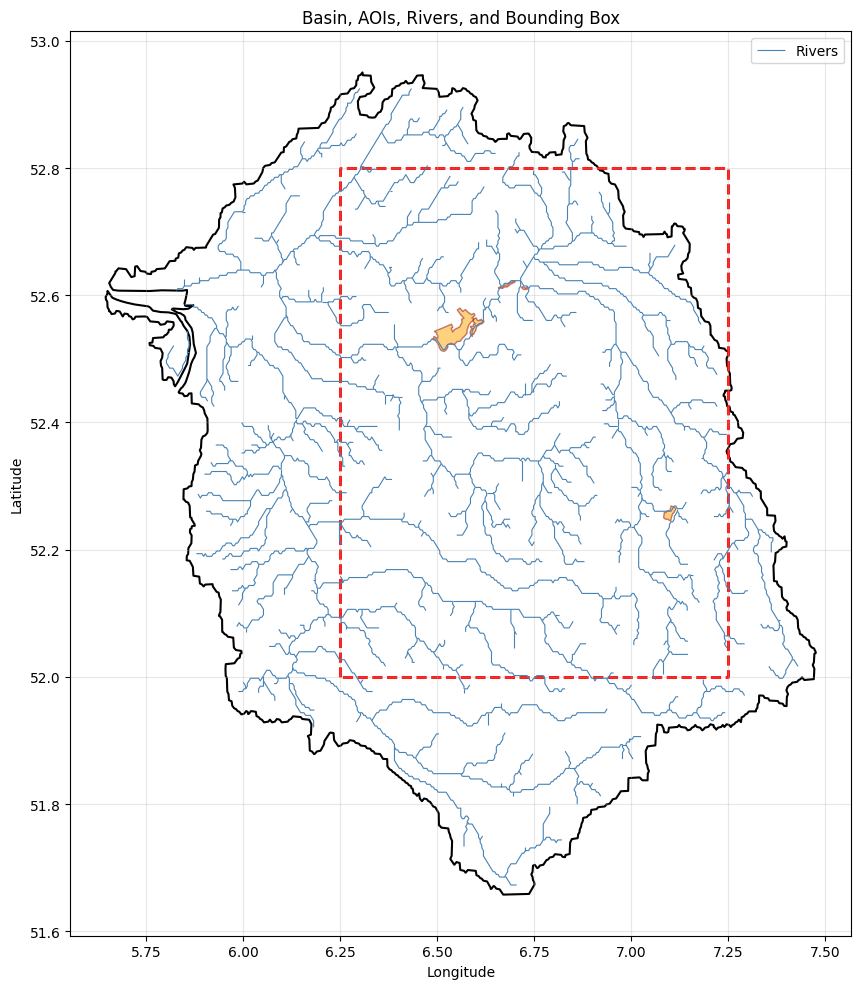

In [24]:


site_name = 'vecht'

basin = gpd.read_file('/Users/vm/Downloads/OneDrive_1_04-04-2026/basin/vecht_lv06.shp')
aois = gpd.read_file('/Users/vm/Downloads/OneDrive_1_04-04-2026/Evaluation_sites/Evaluation_site_update.shp')
rivers = gpd.read_file('/Users/vm/Downloads/OneDrive_1_04-04-2026/rivers/rivers_vecht.shp')

# Ensure all layers use the same CRS
if aois.crs != basin.crs:
    aois = aois.to_crs(basin.crs)
if rivers.crs != basin.crs:
    rivers = rivers.to_crs(basin.crs)

# Create a bounding box polygon for the specified lon/lat limits

bbox = box(lon_min, lat_min, lon_max, lat_max)
bbox_gdf = gpd.GeoDataFrame([1], geometry=[bbox], crs=basin.crs)

fig, ax = plt.subplots(figsize=(10, 10))

basin.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, label="Basin")
aois.plot(ax=ax, facecolor="orange", edgecolor="darkred", alpha=0.5, label="AOIs")
rivers.plot(ax=ax, color="steelblue", linewidth=0.8, label="Rivers")
bbox_gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2, linestyle="--", label="Bounding Box")

ax.set_title("Basin, AOIs, Rivers, and Bounding Box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
# ax.set_xlim(lon_min - 0.1, lon_max + 0.1)
# ax.set_ylim(lat_min - 0.1, lat_max + 0.1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Period of interest

In [28]:
poi = ['2017-01-01', '2025-12-31']
startYear = int(poi[0][:4])
endYear = int(poi[1][:4])

# Source EO data 

In [29]:
## Connect to the openEO back-end and authenticate
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()
# List collections available on the openEO back-end
# connection.list_collection_ids()
# Get detailed metadata of a certain collection
# connection.describe_collection("SENTINEL2_L2A")

## Set geographical limits of the bounding box
W = bbox_gdf.total_bounds[0]
S = bbox_gdf.total_bounds[1]
E = bbox_gdf.total_bounds[2]
N = bbox_gdf.total_bounds[3]

Authenticated using refresh token.


## Sentinel-2 : NDWI

In [ ]:
datacube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": W, "south": S, "east": E, "north": N,}, # "crs": "EPSG:4326"
    temporal_extent = poi,
    bands=["B03","B08", "SCL"],
    max_cloud_cover=30)

## From this data cube, we can now select the individual bands with the DataCube.band() method and rescale the digital number values to physical reflectances:
B03 = datacube.band("B03") * 0.0001
B08 = datacube.band("B08") * 0.0001
SCL = datacube.band("SCL") # Scene classification layer

# Cloud masking using the SCL band
cloud_mask =  ((SCL == 8) | (SCL == 9) | (SCL == 3)) * 1.0

# Apply the cloud mask
masked_cube = datacube.mask(cloud_mask)

# Recalculate the bands after masking
B03_masked = masked_cube.band("B03") * 0.0001
B08_masked = masked_cube.band("B08") * 0.0001

# Calculate NDWI
ndwi_cube = (B03_masked-B08_masked) / (B03_masked+B08_masked)

# Create output directory if it doesn't exist
output_dir = f'/Users/vm/Desktop/dir/spongeworks/eo_data/'
os.makedirs(output_dir, exist_ok=True)
# Define output file path
output_file = os.path.join(output_dir, f'ndwi_cube_{site_name}_{startYear}_{endYear}.nc')

job = ndwi_cube.create_job(title=f"S2_NDWI_{site_name}")
job.start_and_wait()
job.get_results().download_files(output_file)

0:00:00 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': send 'start'
0:00:15 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': created (progress 0%)
0:00:20 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': created (progress 0%)
0:00:27 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': created (progress 0%)
0:00:35 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:00:45 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:00:57 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:01:13 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:01:32 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:01:56 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:02:26 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:03:04 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)
0:03:51 Job 'cdse-j-2604041247464cb3a0a1efed9d67398c': running (progress N/A)

<!-- ## Sentinel 2 : Backscatter  -->

<!-- ## Sentinel-1 : Backscatter  -->

<!-- ## Sentinel-1 backscatter -->

In [ ]:
# datacube = connection.load_collection("SENTINEL1_GRD",
#                                         spatial_extent={"west": W, "south": S, "east": E, "north": N,"crs": "EPSG:4326"},
#                                         temporal_extent = poi, 
#                                         bands=["VV","VH"])

# s1_scatter = datacube.sar_backscatter(coefficient="sigma0-ellipsoid", elevation_model="COPERNICUS_30", noise_removal=True)
# s1bs = s1_scatter.apply(lambda x: 10 * x.log(base=10))

# # Create output directory if it doesn't exist
# output_dir = '/Users/vm/Desktop/dir/spongeworks/eo_data/'
# os.makedirs(output_dir, exist_ok=True)

# # Define output file path
# output_file = os.path.join(output_dir, f'S1_backscatter_{site_name}_{startYear}_{endYear}.nc')

# job = s1bs.create_job(title=f"S1_Backscatter_{site_name}")
# job.start_and_wait()
# job.get_results().download_files(output_file)

## Soil Moisture 

In [ ]:
datacube = connection.load_collection(
    "CGLS_SSM_V1_EUROPE",
    spatial_extent={"west": W, "south": S, "east": E, "north": N}, # "crs": "EPSG:4326"
    temporal_extent=poi,
    bands=["ssm"])

job = datacube.create_job(title=f"soil_moisture_{site_name}")
job.start_and_wait()
job.get_results().download_files(f"/Users/vm/Desktop/dir/spongeworks/eo_data/ssm_{startYear}_{endYear}/")

tif_files = sorted(glob(f"/Users/vm/Desktop/dir/spongeworks/eo_data/ssm_{startYear}_{endYear}/*.tif"))

if not tif_files : raise FileNotFoundError("No .tif files found in the target folder.")

# Read each tif as DataArray, drop singleton band dimension if present
ssm_list = [rioxarray.open_rasterio(fp).squeeze(drop=True) for fp in tif_files]

# Extract date from filename using characters between -15 and -5
date_strs = [fp.split("/")[-1][-15:-5] for fp in tif_files]
time_values = pd.to_datetime(date_strs, format="%Y-%m-%d", errors="coerce")

if time_values.isna().any():
    bad = [tif_files[i] for i, v in enumerate(time_values.isna()) if v][:5]
    raise ValueError(f"Could not parse dates from some filenames. Examples: {bad}")

# Concatenate along time
ssm_merged = xr.concat(ssm_list, dim="time").assign_coords(time=time_values)

# Convert to Dataset and save
ssm_ds = ssm_merged.to_dataset(name="ssm")
out_nc = f"/Users/vm/Desktop/dir/spongeworks/eo_data/ssm_{site_name}_{startYear}_{endYear}.nc"
ssm_ds.to_netcdf(out_nc)

# Plot 

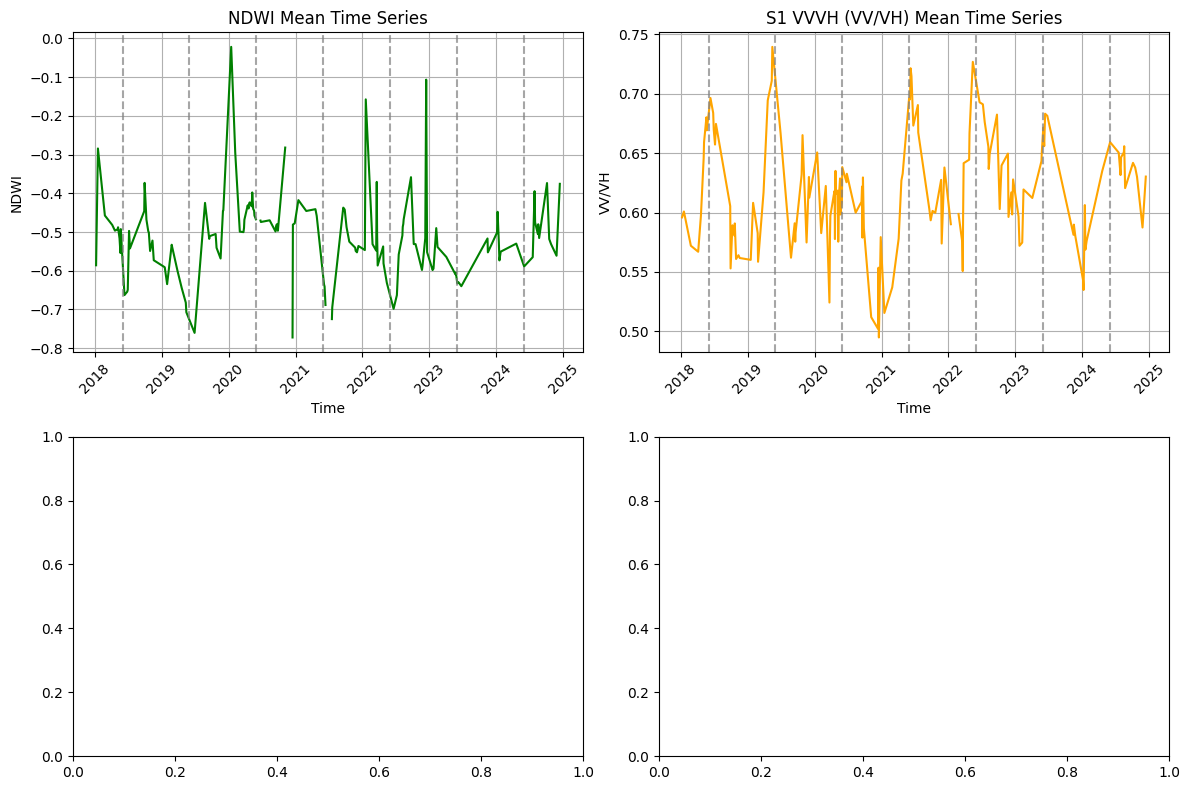

In [ ]:
ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
s1['VVVH'] = s1.VV / s1.VH

# Compute mean values over the spatial dimensions for time series
ndwi_mean = ndwi["var"].mean(dim=["x", "y"])
s1_vv_mean = s1["VV"].mean(dim=["x", "y"])
s1_vh_mean = s1["VH"].mean(dim=["x", "y"])

# Compute mean VV/VH and interpolate to NDWI time axis
vvvh_mean = s1["VVVH"].mean(dim=["x", "y"])
vvvh_interp = vvvh_mean.interp(t=ndwi["var"]["t"])

# met_DF.index = pd.to_datetime(met_DF['date'])
# met_DF = met_DF['2018':'2024']
# Calculate cumulative precipitation that resets each 1 January
# total_prec_cum = met_DF['prec'].groupby(met_DF.index.year).cumsum()

# Get all June 1st dates in the time range for vertical lines
years = np.unique([pd.to_datetime(d).year for d in ndwi_mean["t"].values])
june_dates = [np.datetime64(f"{y}-06-01") for y in years]

# Create the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})

# Plot time series of mean values
axes[0, 0].plot(ndwi_mean["t"].values, ndwi_mean.values, label="NDWI", color="green")
axes[0, 0].set_title("NDWI Mean Time Series")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("NDWI")
axes[0, 0].grid()
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0, 0].tick_params(axis='x', rotation=45)
for jd in june_dates:
    axes[0, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)

axes[0, 1].plot(ndwi_mean["t"].values, vvvh_interp.values, label="S1 VVVH (VV/VH)", color="orange")
axes[0, 1].set_title("S1 VVVH (VV/VH) Mean Time Series")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("VV/VH")
axes[0, 1].grid()
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0, 1].tick_params(axis='x', rotation=45)
for jd in june_dates:
    axes[0, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)


# # Plot cumulative precipitation
# axes[1, 0].plot(total_prec_cum.index, total_prec_cum.values, color="dodgerblue", label="Cumulative Precipitation")
# axes[1, 0].set_title("Cumulative Precipitation (reset yearly)")
# axes[1, 0].set_xlabel("Time")
# axes[1, 0].set_ylabel("Cumulative Precipitation (m)")
# axes[1, 0].grid()
# axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())
# axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[1, 0].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[1, 0].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# axes[1, 0].legend()

# # Plot total daily precipitation instead of cumulative
# axes[1, 1].plot(met_DF.index, met_DF['prec'], color="dodgerblue", label="Daily Precipitation")
# axes[1, 1].set_title("Total Daily Precipitation")
# axes[1, 1].set_xlabel("Time")
# axes[1, 1].set_ylabel("Precipitation (m)")
# axes[1, 1].grid()
# axes[1, 1].xaxis.set_major_locator(mdates.YearLocator())
# axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# axes[1, 1].tick_params(axis='x', rotation=45)
# for jd in june_dates:
#     axes[1, 1].axvline(jd, color='grey', linestyle='--', alpha=0.7)
# axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ndwi["var"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
#     clim=(ndwi["var"].min().item(), ndwi["var"].max().item())  # Set color scale limits
# )

In [ ]:
# ndwi["high"] = ndwi['var'].where(ndwi["var"]>=0)
# ndwi["high"].hvplot(
#     x='x', 
#     y='y', 
#     cmap='Greens', 
#     title='NDWI Map', 
# )

In [ ]:
ndwi = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/ndwi_cube.nc',engine='netcdf4')
ndwi = ndwi.rename_vars({'var':'ndwi'})
s1 = xr.open_dataset('/Users/vm/Documents/Scripts and Data/data/spongeworks/sar_bs.nc',engine='netcdf4')
s1['VVVH'] = s1.VV / s1.VH


output_dir = "ndwi_frames"
os.makedirs(output_dir, exist_ok=True)

# Read the GeoJSON file containing the stream feature
points = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/points.geojson')
# Transform the stream to the desired CRS
points.geometry = points.geometry.to_crs("EPSG:4326")
points = points.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

stream = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/stream.geojson')
stream.geometry = stream.geometry.to_crs("EPSG:4326")
stream = stream.set_crs(4326,allow_override=True)  # Replace 4326 with the current CRS of the stream data

# Get the global min and max values for the color scale
vmin = ndwi["ndwi"].min().item()
vmax = ndwi["ndwi"].max().item()

# Generate frames for each time step
time_steps = ndwi["t"]  # Replace "t" with the name of your time dimension
frame_paths = []

for i, time in enumerate(time_steps):

    # Create the plot for the current time step
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ndwi["ndwi"].sel(t=time).plot(cmap="vanimo_r", vmin=-1, vmax=1)  # Fix color scale
    
    # Add the stream feature as an overlay
    stream.plot(ax=ax, color="blue", linewidth=1, label="Stream")  # Customize color and line width
    points.plot(ax=ax, color="red", linewidth=1, label="Points")  # Customize color and line width

    # # Add a colorbar with a shrink factor to scale it proportionally
    # cbar = fig.colorbar(im, ax=ax, shrink=0.8)  # Adjust shrink to control colorbar size
    # cbar.set_label("NDWI Value")
    
    # Add title, labels, and legend
    ax.set_title(f"NDWI Map - Time: {str(pd.to_datetime(time.values))[:10]}", fontsize=14)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.legend(loc="upper right")  # Add legend for the stream feature
    
    # Save the plot as a PNG file
    frame_path = os.path.join(output_dir, f"frame_{i:03d}.png")
    plt.savefig(frame_path, dpi=150)
    plt.close()
    frame_paths.append(frame_path)

# Create a .gif from the saved frames
gif_path = "/Users/vm/Desktop/ndwi_animation.gif"
with imageio.get_writer(gif_path, mode='I', duration=15) as writer:  # Adjust duration for frame speed
    for frame_path in frame_paths:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"Animation saved as {gif_path}")

# # Optional: Clean up temporary frame files
# for frame_path in frame_paths:
#     os.remove(frame_path)

In [ ]:
points = points[points.name.isin(['Bund-1','Bund-3'])]
# Loop through each point and crop ndwi and s1 datasets individually
cropped_results = []
buffer_deg  = 0.0001  # Buffer size in degrees
for idx, row in points.iterrows():
    # Get point coordinates
    pt = row.geometry
    # Buffer around the point (in degrees)
    minx, miny = pt.x - buffer_deg, pt.y - buffer_deg
    maxx, maxy = pt.x + buffer_deg, pt.y + buffer_deg

    # Crop ndwi and s1 datasets to the bounding box for this point
    ndwi_clip = ndwi.sel(x=slice(minx, maxx), y=slice(maxy, miny))
    s1_clip = s1.sel(x=slice(minx, maxx), y=slice(maxy, miny))

    cropped_results.append({
        "name": row["name"],
        "ndwi_cropped": ndwi_clip,
        "s1_cropped": s1_clip
    })

    print(f"{row['name']} - ndwi shape: {ndwi_clip['ndwi'].shape}, s1 shape: {s1_clip['VV'].shape}")
    # Save the clipped NDWI and S1 datasets for each point
    ndwi_clip.to_netcdf(f"{row['name']}_ndwi_clip.nc")
    s1_clip.to_netcdf(f"{row['name']}_s1_clip.nc")

In [ ]:
point_names = ["Bund-1", "Bund-3"]

for name in point_names:
    ndwi_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir/Spongeworks/{name}_ndwi_clip.nc")
    s1_cropped = xr.open_dataset(f"/Users/vm/Desktop/dir/Spongeworks/{name}_s1_clip.nc")

    # Interpolate both NDWI and VV/VH means to a common time axis (NDWI's time)
    ndwi_cropped_mean = ndwi_cropped["ndwi"].mean(dim=["x", "y"])
    vvvh_cropped_mean = s1_cropped["VVVH"].mean(dim=["x", "y"])
    # Interpolate VV/VH to NDWI time
    vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped["t"])
    # Interpolate NDWI to NDWI time (identity, but for consistency)
    ndwi_interp = ndwi_cropped_mean.interp(t=ndwi_cropped["t"])

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = "forestgreen"
    color2 = "royalblue"

    ax1.set_xlabel("Time")
    ax1.set_ylabel("NDWI (mean)", color=color1)
    ax1.plot(
        ndwi_cropped_mean["t"].values,
        ndwi_interp.values,
        color=color1,
        label="NDWI (mean)",
        linewidth=2.5,
    )
    ax1.tick_params(axis="y", labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.set_ylabel("VV/VH (mean, interpolated)", color=color2)
    ax2.plot(
        ndwi_cropped_mean["t"].values,
        vvvh_interp.values,
        color=color2,
        label="VV/VH (interp)",
        linewidth=2.5,
        linestyle="--",
    )
    ax2.tick_params(axis="y", labelcolor=color2)

    fig.tight_layout()
    plt.title(f"{name}: NDWI and VV/VH Mean Time Series")
    plt.show()


In [ ]:
import seaborn as sns
from scipy.stats import linregress

# Interpolate vvvh_cropped_mean to NDWI time for co-temporal points
vvvh_interp = vvvh_cropped_mean.interp(t=ndwi_cropped_mean["t"])

# Remove NaNs for scatter/hex plot
mask = (~np.isnan(ndwi_cropped_mean.values)) & (~np.isnan(vvvh_interp.values))
x = ndwi_cropped_mean.values[mask]
y = vvvh_interp.values[mask]

plt.figure(figsize=(7, 5))
g = sns.jointplot(x=x, y=y, kind="hex", color="teal", height=6)

# Overlay actual data points
g.ax_joint.scatter(x, y, color="red", s=18, alpha=0.7, label="Data points")

g.ax_joint.legend(loc="upper left")
g.set_axis_labels("NDWI (mean, cropped)", "VV/VH (mean, cropped, co-temporal)")
plt.suptitle("Hexbin plot of NDWI vs VV/VH (co-temporal)", y=1.02)
plt.show()


In [ ]:
landcover = xr.open_dataset 

## Land Cover 


In [ ]:
import json
import joblib
import requests as r
from glob import glob
import time
import rioxarray
import gc
from datetime import datetime, timedelta
import warnings

import openeo
import earthaccess

WRK_DIR = '/Users/vm/Desktop/dir/spongeworks/data/'
IN_DIR = os.path.join(WRK_DIR, 'eo')
AOI_JSON = '/Users/vm/Desktop/dir/spongeworks/data/aoi.geojson'
API_URL = 'https://appeears.earthdatacloud.nasa.gov/api/'
USER = os.getenv('APPEEARS_USER', 'vmyrg')
PASSWORD = os.getenv('APPEEARS_PASSWORD', 'CU5-HxX-HyT-AfU')
TASK_NAME = 'spongeworks_modis'
OUTPUT_FORMAT = 'netcdf4'
START_DATE = '01-01-2017'
END_DATE = '01-01-2025'
    
if not os.path.exists(IN_DIR):
    os.makedirs(IN_DIR)
os.chdir(IN_DIR)

if os.path.exists(os.path.join(IN_DIR, TASK_NAME)):
    print(f"Data already exists at {os.path.join(IN_DIR, TASK_NAME)}. Skipping download and processing.")
else:
    # ... (Your existing AppEEARS download logic goes here, unchanged) ...
    # --- Authenticate with AppEEARS API ---
    token_response = r.post(f'{API_URL}login', auth=(USER, PASSWORD)).json()
    token = token_response['token']
    headers = {'Authorization': f'Bearer {token}'}

    # --- Get available products from AppEEARS ---
    product_response = r.get(f'{API_URL}product').json()
    print(f"AρρEEARS currently supports {len(product_response)} products.")
    products = {p['ProductAndVersion']: p for p in product_response}

    # --- Helper: Search products by keyword in description ---
    def print_products_by_keyword(keyword):
        for p in product_response:
            if keyword in p['Description']:
                pprint.pprint(p)

    # --- Select layers to download (GPP, LAI, FPAR, Land Cover) ---
    layers = []
    # LAI
    X_product = 'MCD15A2H.061'
    layers.append({'product': X_product, 'layer': 'Lai_500m'})
    # FPAR
    X_product = 'MCD15A2H.061'
    X_layers = ['Fpar_500m']
    for layer in X_layers:
        layers.append({'product': X_product, 'layer': layer})
    # Land Cover
    X_product = 'MCD12Q1.061'
    X_layers = ['LC_Type5','QC']
    for layer in X_layers:
        layers.append({'product': X_product, 'layer': layer})

    # --- Read AOI as GeoJSON and get projection ---
    nps = gpd.read_file(AOI_JSON)
    if nps.empty:
        raise ValueError(f"The AOI file '{AOI_JSON}' is empty or invalid.")
    nps_json = json.loads(nps.to_json())
    projections = r.get(f'{API_URL}spatial/proj').json()
    projs = {p['Name']: p for p in projections}
    projection_name = projs['geographic']['Name']

    # --- Build and submit AppEEARS area task ---
    task = {
        'task_type': 'area',
        'task_name': TASK_NAME,
        'params': {
            'dates': [{'startDate': START_DATE, 'endDate': END_DATE}], # collect MODIS data 2000-2017 if simulation starts < 2017
            'layers': layers,
            'output': {
                'format': {'type': OUTPUT_FORMAT},
                'projection': projection_name
            },
            'geo': nps_json,
        }
    }
    task_response = r.post(f'{API_URL}task', json=task, headers=headers).json()
    if "task_id" in task_response:
        task_id = task_response["task_id"]
        print("Task submitted:", task_id)
    else:
        print("Task submission failed:", task_response.get("message", task_response))
        raise RuntimeError(f"Task submission failed: {task_response.get('message', task_response)}")

    # --- Wait for AppEEARS task to complete ---
    def wait_for_task_completion(api_url, task_id, headers):
        while True:
            resp = r.get(f'{api_url}task/{task_id}', headers=headers).json()
            if 'status' in resp:
                status = resp['status']
                print("Task status:", status)
                if status == 'done':
                    break
            else:
                print("Unexpected response:", resp)
                break
            time.sleep(20)
    wait_for_task_completion(API_URL, task_id, headers)

    # --- Download AppEEARS results to local directory ---
    dest_dir = os.path.join(IN_DIR, TASK_NAME)
    os.makedirs(dest_dir, exist_ok=True)
    bundle = r.get(f'{API_URL}bundle/{task_id}', headers=headers).json()
    files = {f['file_id']: f['file_name'] for f in bundle['files']}
    for file_id, file_name in files.items():
        dl = r.get(f'{API_URL}bundle/{task_id}/{file_id}', headers=headers, stream=True)
        filename = file_name.split('/')[1] if file_name.endswith('.tif') else file_name
        filepath = os.path.join(dest_dir, filename)
        with open(filepath, 'wb') as f:
            for chunk in dl.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f'Downloaded files can be found at: {dest_dir}')

In [ ]:
LC = xr.open_dataset("/Users/vm/Desktop/dir/spongeworks/data/eo/spongeworks_modis/MCD12Q1.061_500m_aid0001.nc")
LC 

In [ ]:
import matplotlib
import hvplot.xarray

# Extract the land cover type variable (assuming 'LC_Type5' is the variable name)
lc_type = LC['LC_Type5']

# Get the mapping of class values to names from attributes
lc_names = lc_type.attrs.get('flag_values', None)
lc_labels = lc_type.attrs.get('flag_meanings', None)

if lc_names is not None and lc_labels is not None:
    if isinstance(lc_names, str):
        lc_names = [int(x) for x in lc_names.split()]
    if isinstance(lc_labels, str):
        lc_labels = lc_labels.split()

    cmap = matplotlib.cm.get_cmap('tab20', len(lc_names))
    color_mapping = {v: matplotlib.colors.rgb2hex(cmap(i)) for i, v in enumerate(lc_names)}

    lc_type.hvplot.image(
        x='lon', y='lat', z='LC_Type5',
        cmap=[color_mapping[v] for v in lc_names],
        colorbar=True,
        clim=(min(lc_names), max(lc_names)),
        frame_width=600,
        frame_height=500,
        title='Land Cover (LC_Type5)',
        xlabel='Longitude',
        ylabel='Latitude'
    )
else:
    lc_type.hvplot.image(
        x='lon', y='lat', z='LC_Type5',
        cmap='tab20',
        colorbar=True,
        frame_width=600,
        frame_height=500,
        title='Land Cover (LC_Type5)',
        xlabel='Longitude',
        ylabel='Latitude'
    )


In [ ]:
LC.LC_Type5[0,:,:].plot()